## Analysis of Used Car Prices

### PURPOSE :- This report analyzes used-car pricing to identify the main factors affecting value.

### - Dataset Overview
####  This internal company dataset contains used-car records with key fields such as brand, model, year, mileage, fuel type, transmission, and price.

### - Data Issues Reviewed
#### A few records had missing mileage, one negative mileage value, one future year, some invalid prices, and one unexpected fuel type entry. These were identified and handled during the review process.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [7]:
df = pd.read_csv("used_cars_mock.csv")
df.head(15)

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price
0,1,Honda,Model A,2020,50757.0,Petrol,Manual,7,30,999999
1,2,Fiat,Model B,2030,NaN,Hybrid,Automatic,1,1,19076
2,3,Audi,Model C,2025,-500.0,Petrol,Automatic,12,1,29629
3,4,VW,Model B,2023,10661.0,XYZ,Automatic,10,20,18132
4,5,Dacia,Model C,2015,126515.0,Petrol,Manual,7,30,0
5,6,VW,Model C,2015,121974.0,Petrol,Manual,12,1,500
6,7,BMW,Model B,2005,247373.0,Petrol,Automatic,4,10,500
7,8,Ford,Model B,2025,3210.0,Hybrid,Automatic,11,1,21820
8,9,Mercedes,Model A,2023,34565.0,Diesel,Automatic,11,1,21380
9,10,BMW,Model A,2025,13173.0,Petrol,Automatic,8,30,33616


In [8]:
df_clean = df.copy()
df_clean = df[(df['price'] > 100) & (df['price'] < 500000)]
df_clean = df_clean[df_clean['mileage'] >= 0]
df_clean = df_clean[df_clean['year'] <= 2025]
df_clean = df_clean[df_clean['fuel_type'] != 'XYZ']
median_mileage = df_clean['mileage'].median()
df_clean['mileage'] = df_clean['mileage'].fillna(median_mileage)

### - Key Pricing Drivers
#### The following charts highlight the key drivers of the car price.

### 1. Price vs Year

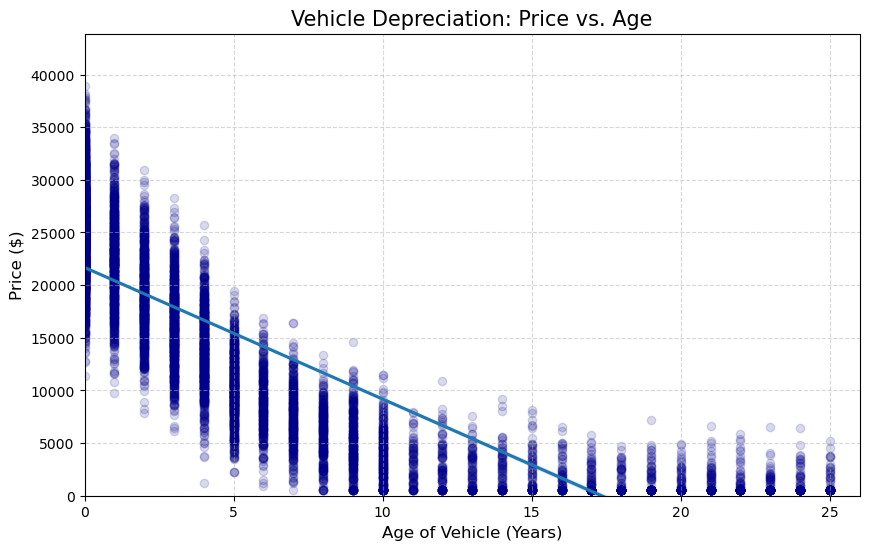

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a clean working copy
df_clean = df.copy()

# 1. Cleaning: Remove non-market prices and future-dated entries
df_clean = df_clean[(df_clean['price'] > 100) & (df_clean['price'] < 100000)]
df_clean = df_clean[df_clean['year'] <= 2025]
df_clean = df_clean[df_clean['mileage'] >= 0]

# 2. Calculate Age (Assuming the current year is 2025)
df_clean['age'] = 2025 - df_clean['year']

# 3. Create the Price vs Age Plot
plt.figure(figsize=(10, 6))
sns.regplot(x='age', y='price', data=df_clean, 
            scatter_kws={'alpha': 0.15, 'color': 'darkblue'})

# Explicitly ensure no negative values on the axes
plt.ylim(0, df_clean['price'].max() + 5000)
plt.xlim(0, df_clean['age'].max() + 1)

plt.title('Vehicle Depreciation: Price vs. Age', fontsize=15)
plt.xlabel('Age of Vehicle (Years)', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### The blue line shows that car's price drop every year
#### Our goal is to 'turn' our inventory before it moves too far down that slope."
#### We need to sell cars aged 0–5 years within 30 days to prevent price depreciation.
#### HYPOTHESIS -- If a vehicle is newer, then its price will be higher, following a standard yearly depreciation schedule where value drops as age increases.

### 2. Price vs Mileage

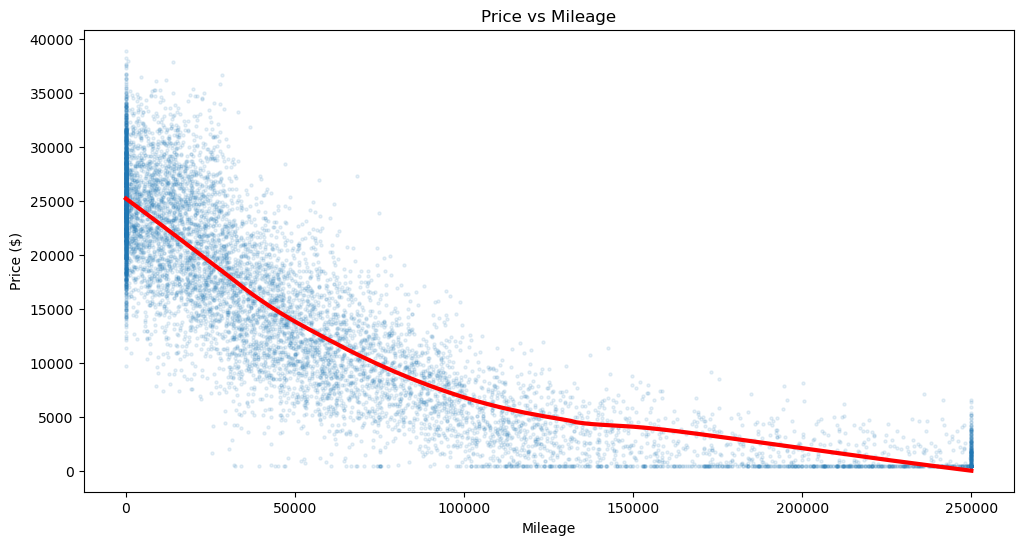

In [42]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.regplot(x='mileage', y='price', data=df_clean, 
            lowess=True, 
            scatter_kws={'alpha':0.1, 's':5},
            line_kws={'color': 'red', 'linewidth': 3})

ax.set_title('Price vs Mileage')
ax.set_xlabel('Mileage')
ax.set_ylabel('Price ($)')

plt.show()

#### “Higher mileage lowers the car’s price, so usage is a major factor.”
#### Our highest turnover and margin potential lies in vehicles with under 50,000 miles.
#### We need to get these cars off our lot while they still feel 'New' to the buyer & before they hit 50,000 miles. If we don't sell it quickly and it hits that 50k mark, we lose thousands of dollars in profit.
#### HYPOTHESIS -- If a car has higher mileage, then its price will decrease, as high usage is the primary indicator of future maintenance costs.

### 3. Price vs Brand

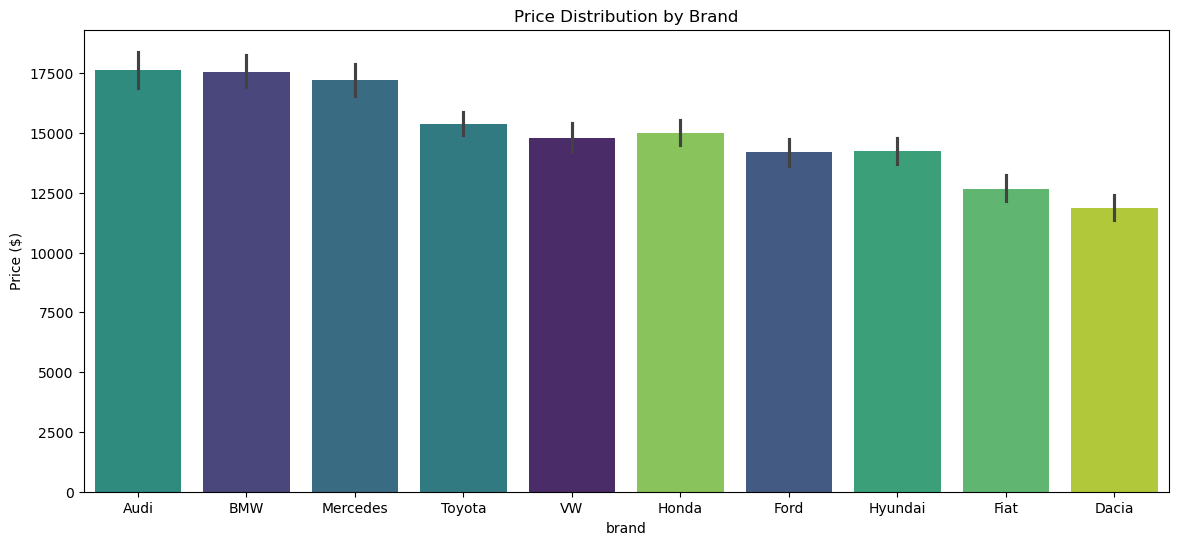

In [36]:
fig, ax = plt.subplots(figsize=(14, 6))


sns.barplot(x='brand', y='price', data=df_clean, order=brand_order, hue = 'brand', palette ='viridis')

ax.set_title('Price Distribution by Brand')
ax.tick_params(axis= 'x', rotation=0)
ax.set_ylabel('Price ($)')

plt.show()



#### We have a clear price ladder. We can target high-profit buyers with luxury brands and high-volume buyers with the budget brands.
#### We are currently well-positioned to cover every budget level, from entry-level buyers to luxury customers.
#### HYPOTHESIS -- Brand significantly influences price — luxury/premium brands (BMW, Mercedes, Audi) command significantly higher prices than economy brands (Ford, Hyundai).

### 4. Number of Cars by Brand

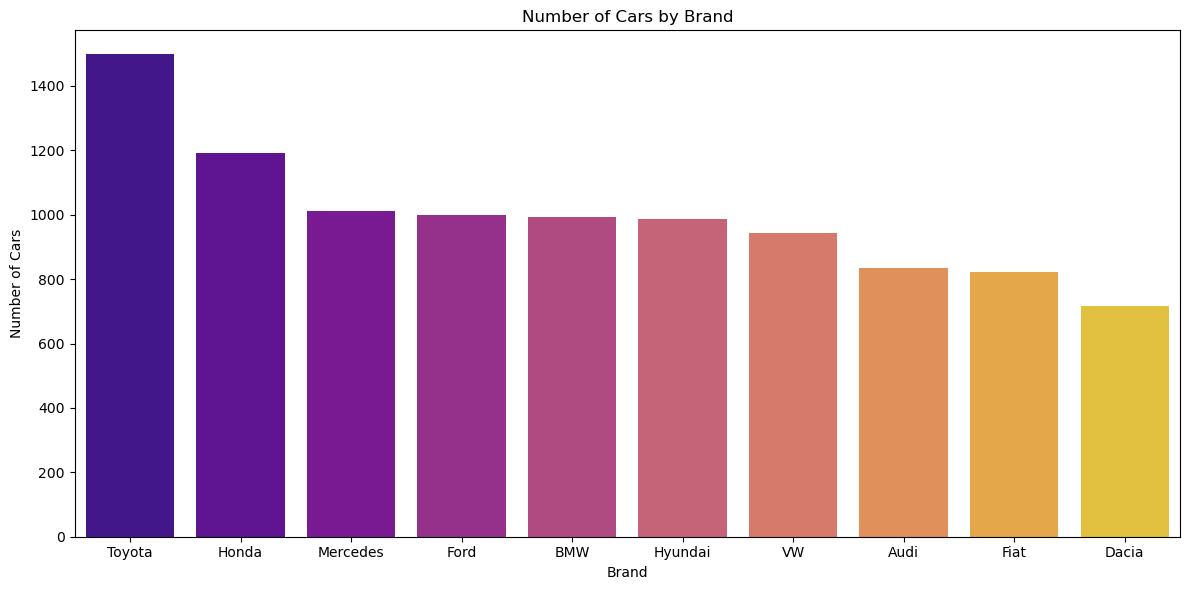

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("used_cars_mock.xlsx")

brand_counts = df["brand"].value_counts().reset_index()
brand_counts.columns = ["brand", "count"]

plt.figure(figsize=(12, 6))
sns.barplot(data=brand_counts, x="brand", y="count", hue="brand", dodge=False, palette="plasma", legend=False)
plt.title("Number of Cars by Brand")
plt.xlabel("Brand")
plt.ylabel("Number of Cars")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Toyota & Honda are our front runners. We are heavily stocked in these brands for consistent, high volume sales.
#### We can also offer our customers a choice of colors because we have a high stock of them.
#### We have relatively low number of luxary cars.
#### While BMW, Audi & Mercedes might make a bigger profit in single sale, the high volume brands like Toyota & Honda can keep the buisness running daily.

### 5. Price vs Transmission

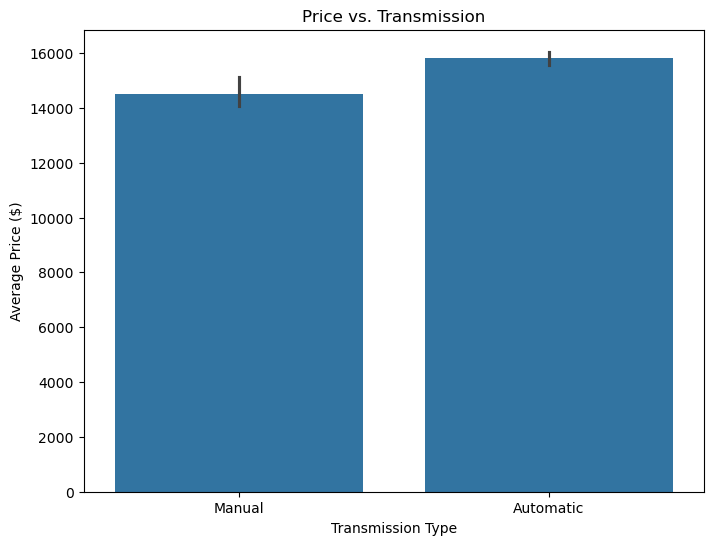

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(x='transmission', y='price', data=df)

plt.title('Price vs. Transmission')
plt.xlabel('Transmission Type')
plt.ylabel('Average Price ($)')

plt.show()

#### Cars with Automatic transmission are expensive than manual ones.
#### HYPOTHESIS -- If a car has an Automatic transmission, then it will command a higher market price than Manual versions due to the modern preference for driving convenience.

### 6. Transmission vs Age vs Price

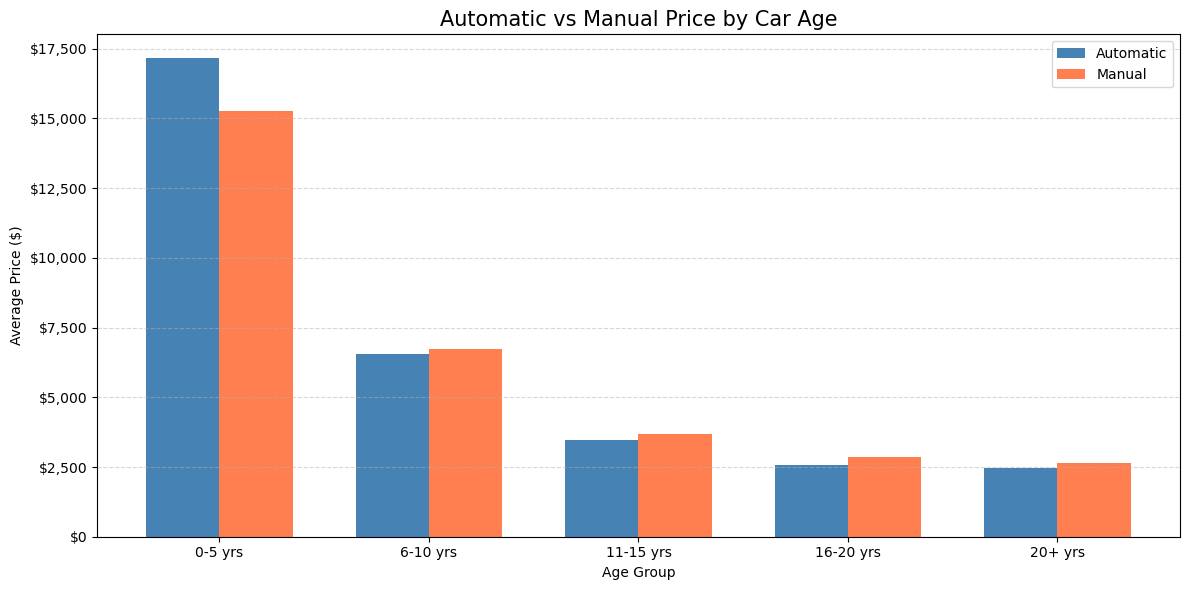

In [84]:
# Calculate avg price
result = df.groupby(['age_group', 'transmission'], observed=True)['price'].mean().unstack()

# Plot
x = np.arange(len(result.index))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, result['Automatic'], width, label='Automatic', color='steelblue')
ax.bar(x + width/2, result['Manual'],    width, label='Manual',    color='coral')

ax.set_title('Automatic vs Manual Price by Car Age', fontsize=15)
ax.set_xlabel('Age Group')
ax.set_ylabel('Average Price ($)')
ax.set_xticks(x)
ax.set_xticklabels(result.index)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### As car gets older, their value drops significantly. New cars are most expensive, while the price of cars for over 5 years drops rapidly
#### Automatic cars are most expensive than manual when they are 0-5 year old. After 5 years, the price difference becomes very small.
#### As we can see manual cars hold the value at their best compared to automatic.
#### HYPOTHESIS -- An Automatic transmission adds extra value to new cars only, but for old cars, the price will be about the same regardless of the transmission.

### 7. Price vs Fuel type

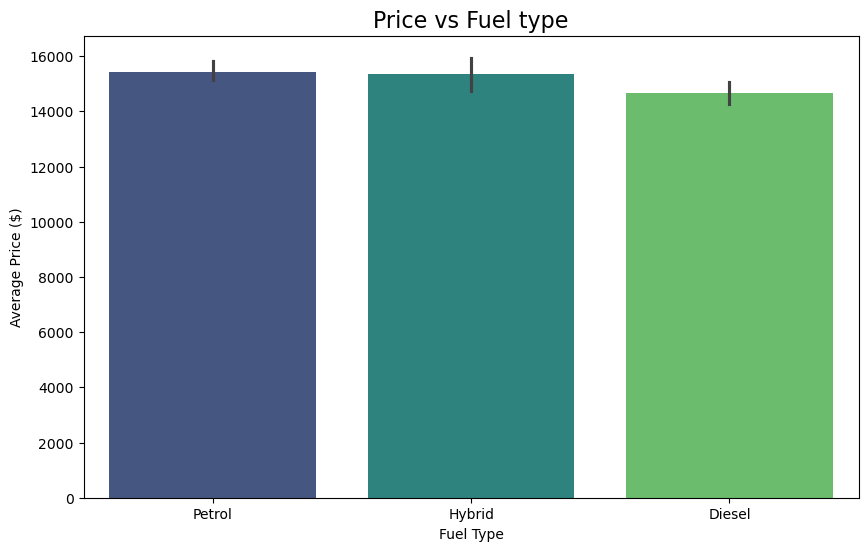

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_filtered = df[df['fuel_type'].isin(['Petrol', 'Diesel', 'Hybrid'])]

plt.figure(figsize=(10, 6))
sns.barplot(x='fuel_type', y='price', data=df_filtered, hue = 'fuel_type', palette='viridis', legend=False)

plt.title('Price vs Fuel type', fontsize=16)
plt.xlabel('Fuel Type')
plt.ylabel('Average Price ($)')

plt.show()

#### Petrol & Hybrid fuel types have the highest average prices. Diesel cars are slightly cheaper .
#### Even though Hybrid technology is newer, it is priced almost same to Petrol. This indicates a strong demand for Hybrids in the used car market
#### HYPOTHESIS -- Hybrid cars will be the most expensive because they are newer technology and save money on gas.

### 8. Avergae Price and Sales per Month

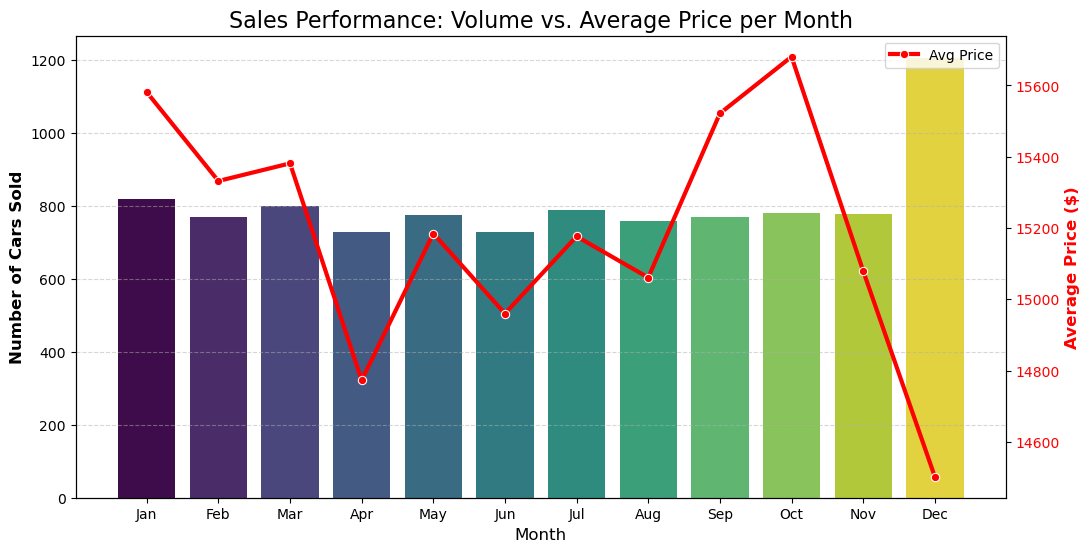

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Aggregate both Sales Volume (Count) and Average Price (Mean)
monthly_stats = df_clean.groupby('sale_month')['price'].agg(['count', 'mean']).reset_index()
monthly_stats.columns = ['Month', 'Cars_Sold', 'Avg_Price']

# 3. Create the Multivariate Chart (Dual Axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Axis: Bar Chart for Sales Volume
sns.barplot(x='Month', y='Cars_Sold', data=monthly_stats, hue='Month', palette='viridis', ax=ax1, legend=False)
ax1.set_ylabel('Number of Cars Sold', fontsize=12, fontweight='bold')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_title('Sales Performance: Volume vs. Average Price per Month', fontsize=16)

# Secondary Axis: Line Chart for Average Price
ax2 = ax1.twinx()
sns.lineplot(x=range(12), y=monthly_stats['Avg_Price'], color='red', marker='o', linewidth=3, ax=ax2, label='Avg Price')
ax2.set_ylabel('Average Price ($)', color='red', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red')

# Format X-axis with Month Names
plt.xticks(ticks=range(0, 12), 
           labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Clean up and show
ax1.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### For almost the whole year, we sold cars every month. This is great because it means our business is steady.
#### In the month of december, sales are huge because of the festive season. We sold way more than any other month.
#### Crucial Period: Now everyday car sits on the lot, it loses value. Discounts can help clear out the cars that have been there for too long before they become even harder to sell.
#### October -- Golden Month
#### People are willing to pay more in October because of new models and upcoming festive season. We should stick to the high prices to keep our profits high.  
#### In october the price is at its peak, yet the number of cars sold stays steady around 800. This indicate that people didn't walk away from higher prices.
#### We should also fill the lot with newest and fanciest models.  Now the extra money we gained in the October month can be used to cover the big discounts we'll have to give in December to clear out the old stock.
#### HYPOTHESIS -- If we look at sales month-by-month, then we will see higher sales volumes for lower-priced cars during the holiday or 'bonus' seasons, as customers look for budget-friendly deals

## - Key Patterns Observed

- #### Age Depreciation — Car prices drop steadily every year
- #### Mileage Threshold — Cars under 50,000 miles sell for significantly more; beyond that, profit drops sharply.
- #### Brand Price Ladder — Fancy cars like Audi, BMW make more money per sale. Fiat & Dacia have least price value among all.
- #### December Sales Spike — Year-end festive season drives the highest monthly sales; mid-year discounts can clear aging inventory.
- #### Stock Concentration - We are heavily stocked in Toyota & Honda because more people can afford and want to buy them.
- #### Strategic Trend- Transmission Premium only for newer vehicles (0–3 years); however, as cars age beyond 4 years, the price difference between Automatic and Manual units effectively disappears.

### Putting It All Together - How different factors connect!

- #### 1. Old age + high mileage = big price drop
##### These two always go together. The older the car, the more miles it has. Both make the price go down at the same time — so a car that is old AND has high mileage loses value the fastest.
- #### 2. Every day the car sits, we lose money
##### The moment a car enters the lot, the clock starts. Cars under 5 years old and under 50,000 miles should be the first ones we try to sell — they are worth the most right now.
- #### 3. October to fill up, December to cash out
##### In October people are happy to pay full price — so stock our best cars and don't give discounts. Use that extra money to offer deals in December when we need to clear out old stock fast.

### _Conclusion & Strategic Recommendations_

#### - This analysis confirms that our highest margins are tied to a '5-year/50k-mile' threshold; selling inventory before these points prevents steep depreciation losses. 
#### - We should stop paying extra for older Automatic cars because after three years, customers stop paying a premium for them. Our best move is to buy 3-year-old cars with high mileage, as they still look new but are much cheaper for us to acquire. By focusing on these specific value trends, we can increase our profit on every sale without needing a bigger budget.